# Paso 4 — Tratar el desequilibrio

El cuaderno anterior dejó un Random Forest con **f1_macro 0,477** sobre
`test_limpio`, y un diagnóstico claro de por qué se queda ahí:

| Clase | Ejemplos en prueba | Recall |
|---|---|---|
| Normal | 30 924 | 0,808 |
| **DoS** | 1 378 | **0,239** |
| **Worms** | 41 | **0,073** |
| **Analysis** | 250 | **0,056** |

El modelo manda casi todas sus dudas a `Exploits`, la clase de ataque con más
ejemplos. Este cuaderno prueba las técnicas que existen para corregir eso.

## Lo que se va a ver

1. **Las tres familias de técnicas** y en qué se diferencian de verdad.
2. **Una partición de validación**, porque elegir la estrategia mirando la prueba
   sería hacer trampa.
3. Que **la técnica más recomendada en internet aquí no hace prácticamente
   nada**, y la que sí funciona no es la más sofisticada.
4. Que **no hay un ganador único**: la estrategia correcta depende de qué cueste
   más, una alarma falsa o un ataque no detectado. Se cuantifican ambas.


## 0. Punto de partida

Se repite la preparación del cuaderno anterior: cargar, codificar con el
`OrdinalEncoder` ajustado **solo con entrenamiento**, y separar características
de etiqueta.

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

# imbalanced-learn avisa de futuros cambios de API que no afectan a este cuaderno.
warnings.filterwarnings("ignore")

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESADO = RAIZ / "datos" / "procesado"
RESULTADOS = RAIZ / "resultados"
RESULTADOS.mkdir(exist_ok=True)

ACENTO = "#5E6AD2"
AVISO = "#e0803c"
GRIS = "#8A8F98"

OBJETIVO = "attack_cat"
CATEGORICAS = ["proto", "service", "state"]
SEMILLA = 42

pd.set_option("display.width", 200)

train = pd.read_parquet(PROCESADO / "train.parquet")
test_limpio = pd.read_parquet(PROCESADO / "test_limpio.parquet")
CARACTERISTICAS = [c for c in train.columns if c not in (OBJETIVO, "label")]

codificador = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
codificador.fit(train[CATEGORICAS])


def preparar(df):
    """Devuelve la matriz de características con las columnas de texto codificadas."""
    X = df[CARACTERISTICAS].copy()
    X[CATEGORICAS] = codificador.transform(df[CATEGORICAS])
    return X.astype(float)


X_train, y_train = preparar(train), train[OBJETIVO]
X_test, y_test = preparar(test_limpio), test_limpio[OBJETIVO]
CLASES = sorted(y_train.unique())

print(f"Entrenamiento: {len(X_train):,} filas")
print(f"Prueba limpia: {len(X_test):,} filas")

Entrenamiento: 96,822 filas
Prueba limpia: 47,716 filas


---

# 1. Primero, una partición de validación

Aquí hay una trampa fácil de pisar y que invalida el resultado entero.

Se van a probar **siete estrategias** y elegir la mejor. Si esa elección se hace
mirando `test_limpio`, el conjunto de prueba deja de ser una prueba: se convierte
en parte del proceso de ajuste. El número final quedaría inflado, exactamente
igual que con la fuga del paso 2 — solo que esta vez la fuga la habría
introducido yo.

**La regla:** el conjunto de prueba se toca **una sola vez**, al final, y solo
para reportar. Todo lo demás se decide sobre una partición separada del
entrenamiento.

La división es **estratificada**, para que validación conserve la proporción
original de cada clase. Sin eso, `Worms` podría no aparecer en absoluto.

In [2]:
X_ajuste, X_val, y_ajuste, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEMILLA
)

reparto = pd.DataFrame({
    "ajuste": y_ajuste.value_counts(),
    "validacion": y_val.value_counts(),
    "prueba": y_test.value_counts(),
}).loc[CLASES]

print(f"ajuste={len(X_ajuste):,}  validacion={len(X_val):,}  prueba={len(X_test):,}\n")
reparto

ajuste=77,457  validacion=19,365  prueba=47,716



,ajuste,validacion,prueba
attack_cat,,,
Analysis,895,224,250
Backdoor,897,224,267
DoS,2695,674,1378
Exploits,15488,3872,7280
Fuzzers,11266,2816,4139
Generic,1440,360,1234
Normal,39115,9779,30924
Reconnaissance,4800,1200,1912
Shellcode,763,191,291


### Una advertencia que hay que llevar hasta el final

**`Worms` se queda con 98 ejemplos para ajustar y 25 para validar.**

Con 25 ejemplos, su recall solo puede tomar 26 valores distintos: cada acierto o
fallo lo mueve **4 puntos de golpe**. Un recall de 0,92 significa «23 de 25», no
«el modelo detecta el 92 % de los gusanos del mundo».

Lo mismo, algo menos grave, en prueba: allí hay 41 ejemplos y cada uno vale 2,4
puntos. **Ninguna conclusión de este cuaderno puede apoyarse solo en `Worms`.**

---

# 2. Las tres familias de técnicas

Todas persiguen lo mismo —que el modelo deje de ignorar las clases pequeñas—
pero actúan en sitios distintos.

### A. Repesado — `class_weight`

No toca los datos. Le dice al algoritmo que **equivocarse en una clase rara
cuesta más**. Con `balanced`, el peso de cada clase es inversamente proporcional
a su frecuencia: un error en `Worms` (98 ejemplos) pesa unas 400 veces más que
uno en `Normal` (39 115).

*A favor:* gratis, no inventa ni tira datos, una sola palabra de código.
*En contra:* si el modelo no puede separar las clases, penalizar más los errores
no le da información nueva.

### B. Sobremuestreo — SMOTE

**Fabrica ejemplos sintéticos** de las clases minoritarias. Para cada ejemplo
real busca sus vecinos más cercanos de la misma clase y genera puntos nuevos
interpolando entre ellos.

*A favor:* no se pierde ningún dato real.
*En contra:* los ejemplos son inventados. Si los 98 `Worms` reales no cubren la
variedad de un gusano de verdad, SMOTE solo rellena el hueco entre los que hay.
Además multiplica el tamaño del conjunto, y con él el tiempo de entrenamiento.

### C. Submuestreo — `RandomUnderSampler`

**Tira filas de las clases grandes** hasta equilibrar.

*A favor:* rapidísimo, y no inventa nada.
*En contra:* tira datos reales. Igualar todo a `Worms` dejaría el entrenamiento
en **980 filas de 77 457** — se descartaría el 98,7 % de la información.

> Por eso se prueba también una versión intermedia: **poner un tope** en lugar de
> igualar del todo. Ese tope resultará ser la decisión importante del cuaderno.

In [3]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


def bosque():
    """Devuelve un Random Forest con la misma configuración del cuaderno anterior."""
    return RandomForestClassifier(n_estimators=200, random_state=SEMILLA, n_jobs=-1)


def evaluar(modelo, X, y):
    """Calcula métricas globales y por clase de un modelo ya entrenado."""
    p = modelo.predict(X)
    return {
        "accuracy": accuracy_score(y, p),
        "f1_macro": f1_score(y, p, average="macro", zero_division=0),
        "recall": pd.Series(
            recall_score(y, p, average=None, labels=CLASES, zero_division=0), index=CLASES
        ),
        "precision": pd.Series(
            precision_score(y, p, average=None, labels=CLASES, zero_division=0), index=CLASES
        ),
    }


conteo_ajuste = y_ajuste.value_counts()
# Clases con las que se mide si una estrategia funciona: las que el baseline falla.
RARAS = ["Worms", "Analysis", "Shellcode", "Backdoor", "DoS"]

print("Clases consideradas raras para el seguimiento:", ", ".join(RARAS))

Clases consideradas raras para el seguimiento:

 Worms, Analysis, Shellcode, Backdoor, DoS


In [4]:
def probar(nombre, X_ent, y_ent, segundos_remuestreo=0.0):
    """Entrena un bosque con los datos dados y lo evalúa sobre validación."""
    inicio = time.perf_counter()
    modelo = bosque().fit(X_ent, y_ent)
    segundos = time.perf_counter() - inicio + segundos_remuestreo
    r = evaluar(modelo, X_val, y_val)
    return {
        "estrategia": nombre,
        "filas": len(X_ent),
        "segundos": round(segundos, 1),
        "accuracy": round(r["accuracy"], 4),
        "f1_macro": round(r["f1_macro"], 4),
        "recall_raras": round(r["recall"][RARAS].mean(), 3),
        "precision_raras": round(r["precision"][RARAS].mean(), 3),
    }, r


ensayos, detalle = [], {}


def registrar(nombre, X_ent, y_ent, seg=0.0):
    fila, r = probar(nombre, X_ent, y_ent, seg)
    ensayos.append(fila)
    detalle[nombre] = r
    print(f"{nombre:32} filas={len(X_ent):>7,}  f1_macro={fila['f1_macro']:.4f}")


registrar("RF base (sin tratar)", X_ajuste, y_ajuste)

RF base (sin tratar)             filas= 77,457  f1_macro=0.4889


In [5]:
# --- Familia A: repesado ---
for peso in ("balanced", "balanced_subsample"):
    inicio = time.perf_counter()
    modelo = RandomForestClassifier(
        n_estimators=200, random_state=SEMILLA, n_jobs=-1, class_weight=peso
    ).fit(X_ajuste, y_ajuste)
    r = evaluar(modelo, X_val, y_val)
    ensayos.append({
        "estrategia": f"class_weight={peso}",
        "filas": len(X_ajuste),
        "segundos": round(time.perf_counter() - inicio, 1),
        "accuracy": round(r["accuracy"], 4),
        "f1_macro": round(r["f1_macro"], 4),
        "recall_raras": round(r["recall"][RARAS].mean(), 3),
        "precision_raras": round(r["precision"][RARAS].mean(), 3),
    })
    detalle[f"class_weight={peso}"] = r
    print(f"class_weight={peso:20} f1_macro={r['f1_macro']:.4f}")

class_weight=balanced             f1_macro=0.5009


class_weight=balanced_subsample   f1_macro=0.5017


In [6]:
# --- Familia B: sobremuestreo ---
inicio = time.perf_counter()
X_smote, y_smote = SMOTE(random_state=SEMILLA, k_neighbors=5).fit_resample(X_ajuste, y_ajuste)
seg_smote = time.perf_counter() - inicio
print(f"SMOTE completo: {len(X_ajuste):,} -> {len(X_smote):,} filas en {seg_smote:.1f}s")
registrar("SMOTE completo", X_smote, y_smote, seg_smote)

# Versión moderada: subir las minorías hasta 5 000, no hasta igualar la mayoría.
objetivo = {c: max(int(conteo_ajuste[c]), 5000) for c in CLASES}
inicio = time.perf_counter()
X_sm, y_sm = SMOTE(random_state=SEMILLA, k_neighbors=5,
                   sampling_strategy=objetivo).fit_resample(X_ajuste, y_ajuste)
seg_sm = time.perf_counter() - inicio
registrar("SMOTE moderado (5 000)", X_sm, y_sm, seg_sm)

SMOTE completo: 77,457 -> 391,150 filas en 0.9s


SMOTE completo                   filas=391,150  f1_macro=0.5067


SMOTE moderado (5 000)           filas=100,869  f1_macro=0.5070


In [7]:
# --- Familia C: submuestreo ---
X_under, y_under = RandomUnderSampler(random_state=SEMILLA).fit_resample(X_ajuste, y_ajuste)
registrar("Submuestreo completo", X_under, y_under)

tope = {c: min(int(conteo_ajuste[c]), 5000) for c in CLASES}
X_tope, y_tope = RandomUnderSampler(
    random_state=SEMILLA, sampling_strategy=tope
).fit_resample(X_ajuste, y_ajuste)
registrar("Submuestreo con tope 5 000", X_tope, y_tope)

Submuestreo completo             filas=    980  f1_macro=0.4303


Submuestreo con tope 5 000       filas= 26,588  f1_macro=0.5224


In [8]:
comparativa = pd.DataFrame(ensayos).set_index("estrategia")
comparativa.sort_values("f1_macro", ascending=False)

,filas,segundos,accuracy,f1_macro,recall_raras,precision_raras
estrategia,,,,,,
Submuestreo con tope 5 000,26588,1.5,0.7767,0.5224,0.311,0.287
SMOTE moderado (5 000),100869,7.0,0.8021,0.5070,0.252,0.244
SMOTE completo,391150,43.3,0.7955,0.5067,0.299,0.210
class_weight=balanced_subsample,77457,5.8,0.8033,0.5017,0.195,0.314
class_weight=balanced,77457,5.7,0.8020,0.5009,0.194,0.310
RF base (sin tratar),77457,7.0,0.8027,0.4889,0.174,0.281
Submuestreo completo,980,0.2,0.6754,0.4303,0.580,0.126


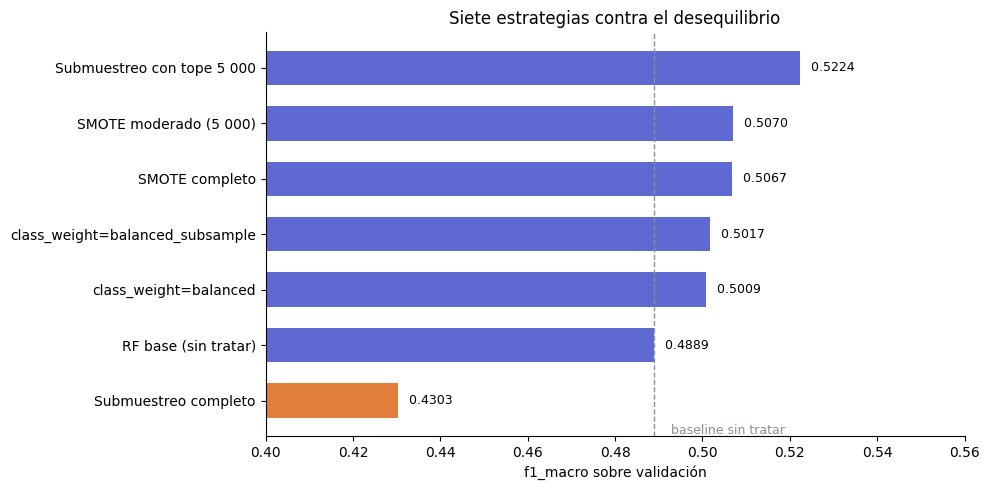

In [9]:
orden = comparativa.sort_values("f1_macro").index
posicion = np.arange(len(orden))
base = comparativa.loc["RF base (sin tratar)", "f1_macro"]

fig, ax = plt.subplots(figsize=(10, 5))
colores = [AVISO if v < base else ACENTO for v in comparativa.loc[orden, "f1_macro"]]
barras = ax.barh(posicion, comparativa.loc[orden, "f1_macro"], color=colores, height=0.62)

ax.axvline(base, color=GRIS, linestyle="--", linewidth=1)
ax.text(base + 0.004, -0.6, "baseline sin tratar", fontsize=9, color=GRIS)

ax.bar_label(barras, labels=[f"  {v:.4f}" for v in comparativa.loc[orden, "f1_macro"]],
             padding=2, fontsize=9)
ax.set_yticks(posicion, orden)
ax.set_xlim(0.40, 0.56)
ax.set_xlabel("f1_macro sobre validación")
ax.set_title("Siete estrategias contra el desequilibrio")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "estrategias-desequilibrio.png", dpi=140)
plt.show()

### Qué se ve aquí

**`class_weight` casi no hace nada.** Es la técnica que más se recomienda —una
palabra, sin coste— y aquí mueve el f1_macro de 0,4889 a 0,5009. Un punto.

Tiene una explicación que conviene entender: penalizar más los errores solo ayuda
si el modelo **puede** acertar y no le compensa. Cuando el problema es que no hay
información suficiente para separar las clases, subir el castigo no aporta nada
nuevo que aprender.

**SMOTE completo cuesta mucho y rinde poco.** Pasa de 77 457 a 391 150 filas y
tarda unos 57 s frente a los 6 s del baseline — **casi nueve veces más** — para
quedarse en 0,5067, medio punto por encima de `balanced_subsample`. La versión
moderada consigue prácticamente lo mismo (0,5070) en 9,5 s: **si se va a usar
SMOTE, no hace falta igualar del todo**.

**El submuestreo completo es el peor de todos** en f1_macro (0,4303). Deja el
entrenamiento en 980 filas: tirar el 98,7 % de los datos no sale a cuenta.

Aunque conviene fijarse en su columna `recall_raras`: **0,580, la más alta de la
tabla, más del triple que el baseline.** El peor modelo según el f1_macro es el
que más ataques raros detecta. Esa contradicción es el tema del apartado
siguiente.

**Gana el submuestreo con tope** (0,5224), que es la opción más simple de todas
las que funcionan: entrena en 2 s con 26 588 filas, un tercio del original.

> Un resultado incómodo para la intuición: **la técnica más sofisticada (SMOTE,
> que fabrica datos) pierde contra la más tosca (tirar filas al azar)**. Merece
> comprobarse por qué.

---

# 3. El tope es la decisión, no la técnica

El 5 000 del apartado anterior salió de la nada. Y como el submuestreo completo
(tope = 98) es el peor y el tope 5 000 es el mejor, **el tope no es un detalle de
configuración: es el mando que controla el comportamiento del modelo**.

Se barre de extremo a extremo y se mira qué pasa. Junto al f1_macro se siguen dos
cosas más:

- **Recall medio de las clases raras** — qué proporción de esos ataques se
  detecta.
- **Precisión media de las clases raras** — de todo lo que el modelo marca como
  tal, qué proporción lo era de verdad.

Las dos juntas, porque por separado cada una se puede falsear: marcarlo todo como
`Worms` da recall 1,0 y precisión ~0.

In [10]:
topes = [98, 250, 500, 1000, 2000, 5000, 10000, 20000, int(conteo_ajuste.max())]
filas_barrido = []

for t in topes:
    objetivo = {c: min(int(conteo_ajuste[c]), t) for c in CLASES}
    Xr, yr = RandomUnderSampler(
        random_state=SEMILLA, sampling_strategy=objetivo
    ).fit_resample(X_ajuste, y_ajuste)
    r = evaluar(bosque().fit(Xr, yr), X_val, y_val)
    filas_barrido.append({
        "tope": t,
        "filas": len(Xr),
        "accuracy": round(r["accuracy"], 4),
        "f1_macro": round(r["f1_macro"], 4),
        "recall_raras": round(r["recall"][RARAS].mean(), 3),
        "precision_raras": round(r["precision"][RARAS].mean(), 3),
        "recall_Worms": round(r["recall"]["Worms"], 3),
        "precision_Worms": round(r["precision"]["Worms"], 3),
        "recall_DoS": round(r["recall"]["DoS"], 3),
    })

barrido = pd.DataFrame(filas_barrido).set_index("tope")
barrido

,filas,accuracy,f1_macro,recall_raras,precision_raras,recall_Worms,precision_Worms,recall_DoS
tope,,,,,,,,
98,980,0.6726,0.4269,0.576,0.124,0.92,0.042,0.242
250,2348,0.7247,0.4748,0.561,0.166,0.80,0.101,0.260
500,4598,0.7335,0.4873,0.560,0.172,0.80,0.139,0.326
1000,8653,0.7421,0.5015,0.507,0.192,0.68,0.262,0.374
2000,14093,0.7533,0.5214,0.448,0.232,0.56,0.368,0.439
5000,26588,0.7767,0.5224,0.311,0.287,0.24,0.429,0.350
10000,41588,0.7888,0.5066,0.224,0.283,0.16,0.308,0.227
20000,58342,0.7967,0.4992,0.191,0.314,0.16,0.444,0.174
39115,77457,0.8046,0.4884,0.170,0.281,0.12,0.300,0.184


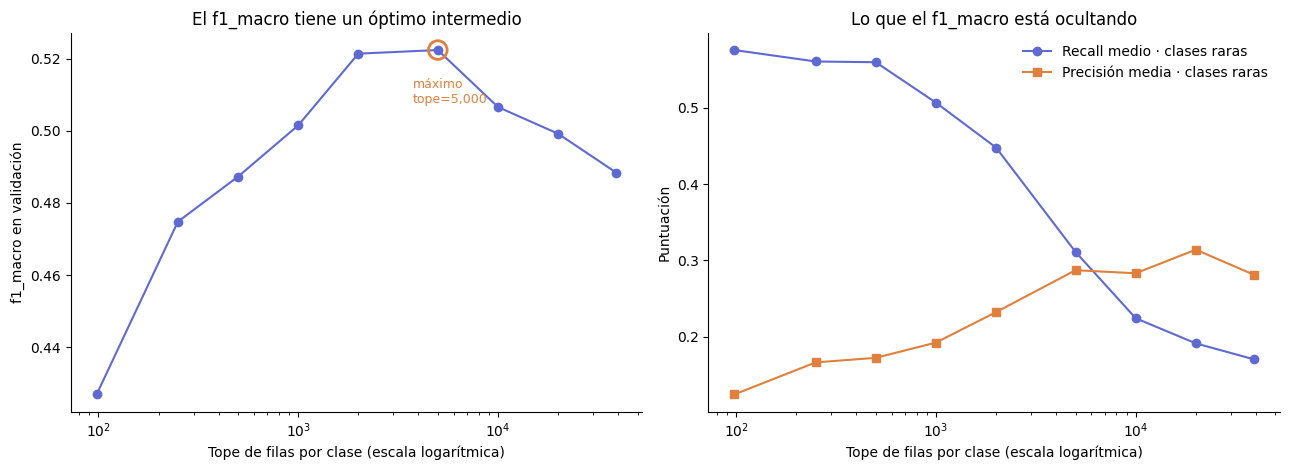

In [11]:
fig, (izq, der) = plt.subplots(1, 2, figsize=(13, 4.8))

izq.plot(barrido.index, barrido["f1_macro"], marker="o", color=ACENTO, label="f1_macro")
mejor = barrido["f1_macro"].idxmax()
izq.scatter([mejor], [barrido.loc[mejor, "f1_macro"]], s=180, facecolors="none",
            edgecolors=AVISO, linewidths=2, zorder=4)
izq.annotate(f"máximo\ntope={mejor:,}", (mejor, barrido.loc[mejor, "f1_macro"]),
             textcoords="offset points", xytext=(-18, -38), fontsize=9, color=AVISO)
izq.set_xscale("log")
izq.set_xlabel("Tope de filas por clase (escala logarítmica)")
izq.set_ylabel("f1_macro en validación")
izq.set_title("El f1_macro tiene un óptimo intermedio")
izq.spines[["top", "right"]].set_visible(False)

der.plot(barrido.index, barrido["recall_raras"], marker="o", color=ACENTO,
         label="Recall medio · clases raras")
der.plot(barrido.index, barrido["precision_raras"], marker="s", color=AVISO,
         label="Precisión media · clases raras")
der.set_xscale("log")
der.set_xlabel("Tope de filas por clase (escala logarítmica)")
der.set_ylabel("Puntuación")
der.set_title("Lo que el f1_macro está ocultando")
der.legend(frameon=False)
der.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig.savefig(RESULTADOS / "barrido-tope.png", dpi=140)
plt.show()

### Qué se ve aquí — y por qué importa tanto

**El gráfico de la izquierda** tiene forma de montaña: el f1_macro sube de 0,4269
(tope 98) a un máximo de **0,5224 en el tope 5 000** y vuelve a bajar hasta 0,4884
sin tope. Ni el equilibrio total ni el desequilibrio original son buena idea.

**El gráfico de la derecha es el importante, y contradice al de la izquierda.**

El recall de las clases raras **no tiene máximo**: crece de forma continua según
baja el tope, de 0,170 sin tratar a **0,576 con el submuestreo completo**. La
precisión hace lo contrario.

Es decir: **el tope que maximiza el f1_macro (5 000) no es el que más ataques
raros detecta.** Con tope 98 se detecta casi el doble de ataques raros, pero la
mayoría de lo que se marca son falsas alarmas.

> **El f1_macro no es una verdad objetiva.** Es una decisión: pondera precisión y
> recall a partes iguales. Si en un IDS un ataque no detectado cuesta más que una
> alarma falsa —que suele ser el caso— entonces **el óptimo de f1_macro no es el
> modelo que hay que desplegar**.

Conviene verlo en el caso extremo. Con tope 98, `Worms` alcanza **recall 0,92**
—23 de los 25 gusanos— pero con una **precisión de 0,042**: de cada 100
conexiones que el modelo marca como gusano, **4 lo son**. Eso no es un detector,
es una alarma permanente.

---

# 4. Evaluación final sobre `test_limpio`

Elegidas las estrategias en validación, toca la única pasada sobre prueba.

Dos detalles del procedimiento que cambian el resultado:

1. **Los finalistas se reentrenan con todo `train`**, validación incluida. Ya no
   hace falta reservarla: la decisión está tomada y descartar 19 365 filas sería
   tirar información gratis.
2. Se llevan **tres topes**, no solo el ganador, para poder enseñar el
   compromiso completo en lugar de un único número.

In [12]:
conteo_train = y_train.value_counts()
finalistas = {
    "RF base (sin tratar)": None,
    "Submuestreo tope 5 000": 5000,
    "Submuestreo tope 1 000": 1000,
    "Submuestreo completo": int(conteo_train.min()),
}

resultados_finales, predicciones = [], {}

for nombre, t in finalistas.items():
    if t is None:
        Xr, yr = X_train, y_train
    else:
        objetivo = {c: min(int(conteo_train[c]), t) for c in CLASES}
        Xr, yr = RandomUnderSampler(
            random_state=SEMILLA, sampling_strategy=objetivo
        ).fit_resample(X_train, y_train)

    modelo = bosque().fit(Xr, yr)
    p = modelo.predict(X_test)
    predicciones[nombre] = p
    resultados_finales.append({
        "estrategia": nombre,
        "filas_ajuste": len(Xr),
        "accuracy": round(accuracy_score(y_test, p), 4),
        "f1_macro": round(f1_score(y_test, p, average="macro", zero_division=0), 4),
        "precision_macro": round(
            precision_score(y_test, p, average="macro", zero_division=0), 4),
        "recall_macro": round(recall_score(y_test, p, average="macro", zero_division=0), 4),
    })
    print(f"{nombre:26} {len(Xr):>7,} filas  ->  f1_macro="
          f"{resultados_finales[-1]['f1_macro']:.4f}")

final = pd.DataFrame(resultados_finales).set_index("estrategia")
final

RF base (sin tratar)        96,822 filas  ->  f1_macro=0.4773


Submuestreo tope 5 000      28,486 filas  ->  f1_macro=0.4911


Submuestreo tope 1 000       9,077 filas  ->  f1_macro=0.4506


Submuestreo completo         1,230 filas  ->  f1_macro=0.3743


,filas_ajuste,accuracy,f1_macro,precision_macro,recall_macro
estrategia,,,,,
RF base (sin tratar),96822,0.7735,0.4773,0.5301,0.4774
Submuestreo tope 5 000,28486,0.6618,0.4911,0.4826,0.5867
Submuestreo tope 1 000,9077,0.6321,0.4506,0.4330,0.6460
Submuestreo completo,1230,0.5924,0.3743,0.3726,0.6022


### Qué se ve aquí

**La mejora en f1_macro es modesta: 0,4773 → 0,4911.** Punto y medio.

Si el cuaderno terminara aquí sería un resultado pobre. Pero mirando las dos
columnas de al lado se ve que **ese número está escondiendo un cambio grande**:

- `recall_macro` sube de **0,477 a 0,587** — el modelo detecta bastante más.
- `precision_macro` baja de **0,530 a 0,483** — y se equivoca bastante más.

El f1_macro, al promediar ambas, casi no se mueve. **Los dos cambios se cancelan
en el promedio aunque son grandes por separado**, que es justo el problema que
tiene resumir un modelo en una sola cifra.

Y `accuracy` cae de 0,774 a **0,662**. Conviene ver qué significa eso en la
práctica.

In [13]:
# El detalle por clase de los dos modelos que interesa comparar.
comparacion = []
for clase in CLASES:
    fila = {"clase": clase, "ejemplos": int((y_test == clase).sum())}
    for nombre in ("RF base (sin tratar)", "Submuestreo tope 5 000"):
        p = predicciones[nombre]
        etiqueta = "base" if "base" in nombre else "tope"
        fila[f"recall_{etiqueta}"] = round(
            recall_score(y_test, p, average=None, labels=[clase], zero_division=0)[0], 3)
        fila[f"precision_{etiqueta}"] = round(
            precision_score(y_test, p, average=None, labels=[clase], zero_division=0)[0], 3)
        fila[f"f1_{etiqueta}"] = round(
            f1_score(y_test, p, average=None, labels=[clase], zero_division=0)[0], 3)
    comparacion.append(fila)

por_clase = pd.DataFrame(comparacion).set_index("clase")
por_clase["cambio_f1"] = (por_clase["f1_tope"] - por_clase["f1_base"]).round(3)
por_clase.sort_values("cambio_f1", ascending=False)

,ejemplos,recall_base,precision_base,f1_base,recall_tope,precision_tope,f1_tope,cambio_f1
clase,,,,,,,,
Worms,41,0.073,0.300,0.118,0.439,0.375,0.404,0.286
DoS,1378,0.239,0.610,0.343,0.496,0.325,0.393,0.050
Generic,1234,0.585,0.949,0.724,0.670,0.884,0.762,0.038
Reconnaissance,1912,0.794,0.767,0.780,0.870,0.726,0.792,0.012
Backdoor,267,0.288,0.274,0.281,0.345,0.247,0.288,0.007
Analysis,250,0.056,0.047,0.051,0.180,0.024,0.042,-0.009
Fuzzers,4139,0.669,0.331,0.443,0.858,0.274,0.415,-0.028
Exploits,7280,0.877,0.734,0.799,0.724,0.795,0.758,-0.041
Shellcode,291,0.385,0.345,0.364,0.663,0.188,0.293,-0.071


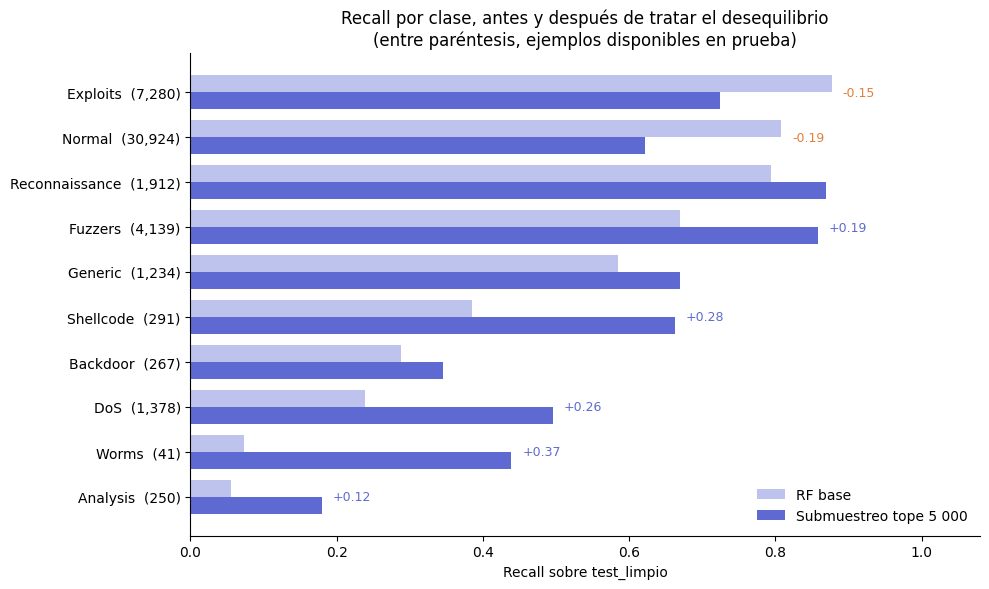

In [14]:
orden = por_clase.sort_values("recall_base").index
posicion = np.arange(len(orden))
alto = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(posicion + alto / 2, por_clase.loc[orden, "recall_base"], alto,
        label="RF base", color=ACENTO, alpha=0.40)
ax.barh(posicion - alto / 2, por_clase.loc[orden, "recall_tope"], alto,
        label="Submuestreo tope 5 000", color=ACENTO)

ax.set_yticks(posicion, [f"{c}  ({int(por_clase.loc[c, 'ejemplos']):,})" for c in orden])
ax.set_xlim(0, 1.08)
ax.set_xlabel("Recall sobre test_limpio")
ax.set_title("Recall por clase, antes y después de tratar el desequilibrio\n"
             "(entre paréntesis, ejemplos disponibles en prueba)")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)

for i, clase in enumerate(orden):
    delta = por_clase.loc[clase, "recall_tope"] - por_clase.loc[clase, "recall_base"]
    if abs(delta) >= 0.10:
        ref = max(por_clase.loc[clase, "recall_base"], por_clase.loc[clase, "recall_tope"])
        ax.text(ref + 0.015, i, f"{delta:+.2f}", va="center", fontsize=9,
                color=ACENTO if delta > 0 else AVISO)

plt.tight_layout()
fig.savefig(RESULTADOS / "recall-antes-despues.png", dpi=140)
plt.show()

### Qué se ve aquí — dónde está la mejora de verdad

El promedio escondía esto:

| Clase | f1 base | f1 con tope | |
|---|---|---|---|
| **Worms** | 0,118 | **0,404** | recall 0,073 → **0,439** |
| **DoS** | 0,343 | **0,393** | recall 0,239 → **0,496** |
| Generic | 0,724 | 0,762 | |
| Backdoor | 0,281 | 0,288 | |
| Reconnaissance | 0,780 | 0,792 | |
| Fuzzers | 0,443 | 0,415 | |
| Exploits | 0,799 | 0,758 | |
| Normal | 0,871 | 0,763 | recall 0,808 → **0,622** |
| Shellcode | 0,364 | 0,293 | |
| Analysis | 0,051 | 0,042 | |

**`Worms` es el cambio real: su f1 se multiplica por 3,4** (0,118 → 0,404), y
detecta 18 de 41 en vez de 3 de 41. Con 41 ejemplos hay que ser prudente, pero la
diferencia es demasiado grande para ser ruido.

**`DoS` duplica su recall** (0,239 → 0,496) con 1 378 ejemplos de prueba. Ese sí
es un resultado sólido.

**`Analysis` sigue rota en las dos versiones** (f1 0,051 y 0,042). Ninguna
estrategia la arregla, y eso encaja con el hallazgo del cuaderno anterior: es una
de las clases con más etiquetas contradictorias (30,2 %). **Parece un límite de
los datos, no del modelo** — se cuantifica en el paso siguiente.

**Lo que se paga:** `Normal` pierde 19 puntos de recall y `Exploits` 4. Eso no es
un detalle contable.

---

# 5. Lo que cuesta en la práctica

`Normal` bajando de 0,808 a 0,622 de recall suena a poca cosa. Traducido a lo que
vería un analista de seguridad, no lo es: son **conexiones normales marcadas como
ataque**, es decir, alarmas falsas.

In [15]:
normales = int((y_test == "Normal").sum())

coste = []
for nombre in ("RF base (sin tratar)", "Submuestreo tope 5 000"):
    p = predicciones[nombre]
    es_normal = (y_test == "Normal").to_numpy()
    falsas_alarmas = int(((p != "Normal") & es_normal).sum())
    ataques_perdidos = int(((p == "Normal") & ~es_normal).sum())
    coste.append({
        "estrategia": nombre,
        "alarmas_falsas": falsas_alarmas,
        "% del trafico normal": round(falsas_alarmas / normales * 100, 1),
        "ataques_no_detectados": ataques_perdidos,
        "% de los ataques": round(ataques_perdidos / int((~es_normal).sum()) * 100, 1),
    })

pd.DataFrame(coste).set_index("estrategia")

,alarmas_falsas,% del trafico normal,ataques_no_detectados,% de los ataques
estrategia,,,,
RF base (sin tratar),5944,19.2,1468,8.7
Submuestreo tope 5 000,11688,37.8,233,1.4


### Qué se ve aquí — el dato que de verdad decide

Los dos errores, contados en conexiones y no en proporciones abstractas:

| | RF base | Tope 5 000 |
|---|---|---|
| Alarmas falsas | 5 944 | **11 688** |
| % del tráfico normal | 19,2 % | 37,8 % |
| **Ataques clasificados como normales** | **1 468** | **233** |
| % de los ataques | 8,7 % | **1,4 %** |

Aquí el intercambio deja de ser abstracto:

- Las alarmas falsas **se duplican**: de 5 944 a 11 688.
- Los ataques que pasan desapercibidos **se reducen a una sexta parte**: de 1 468
  a 233. Del 8,7 % al 1,4 %.

**Esa segunda columna es mucho más favorable de lo que sugería el f1_macro.** El
f1_macro subía 1,4 puntos, un cambio que parecía irrelevante; pero en términos de
ataques que atraviesan el sistema sin ser vistos, el modelo tratado deja pasar
**seis veces menos**.

Conviene entender por qué las dos lecturas discrepan tanto. El f1_macro promedia
las diez clases a partes iguales, así que la mejora enorme en `Worms` pesa lo
mismo que el retroceso en `Shellcode`. La cuenta de arriba, en cambio, pondera
por lo que ocurre de verdad en la red.

> **Ninguna de las dos lecturas es la correcta en abstracto.** Dependen de qué se
> esté pagando. Si cada alerta la revisa una persona, 11 688 falsos positivos
> pueden ser inasumibles. Si el sistema es una primera criba que alimenta a otro
> detector, dejar pasar seis veces menos ataques compensa de sobra.

**Elección para este proyecto: el tope 5 000.** El objetivo declarado desde el
principio era detectar los ataques raros, y ese modelo multiplica por 3,4 el f1 de
`Worms`, duplica el recall de `DoS` y reduce a una sexta parte los ataques no
detectados, sin empeorar el f1_macro.

Lo que no se va a hacer es presentarlo como una mejora sin contrapartida: **cuesta
5 744 alarmas falsas más**, y eso queda escrito junto al resultado.

---

# Resumen

## Lo que se probó

| Estrategia | f1_macro (validación) | Veredicto |
|---|---|---|
| RF base | 0,4889 | referencia |
| `class_weight="balanced"` | 0,5009 | casi no mueve nada |
| `class_weight="balanced_subsample"` | 0,5017 | igual |
| SMOTE completo | 0,5067 | 9× más lento para +0,005 |
| SMOTE moderado | 0,5070 | lo mismo en 9,5 s |
| Submuestreo completo | 0,4303 | el peor en f1_macro… y el mejor en recall de raras |
| **Submuestreo con tope 5 000** | **0,5224** | **ganador** |

## Resultado final — `test_limpio`

| Métrica | RF base | Tope 5 000 |
|---|---|---|
| accuracy | 0,774 | 0,662 |
| **f1_macro** | 0,477 | **0,491** |
| precision_macro | 0,530 | 0,483 |
| recall_macro | 0,477 | **0,587** |
| **f1 de `Worms`** | 0,118 | **0,404** |
| recall de `DoS` | 0,239 | **0,496** |
| Alarmas falsas | 5 944 | 11 688 |
| Ataques no detectados | 1 468 (8,7 %) | **233 (1,4 %)** |

## Los cuatro hallazgos

1. **`class_weight` apenas sirve aquí** (+0,012), pese a ser la recomendación más
   repetida. Penalizar más los errores no da información nueva.

2. **SMOTE no compensa su coste.** Nueve veces más lento que el baseline para
   quedarse por debajo del submuestreo con tope. La técnica más sofisticada
   pierde contra la más simple.

3. **La decisión no era qué técnica, sino dónde poner el tope.** El f1_macro
   tiene un máximo intermedio, pero el recall de las clases raras crece de forma
   continua según se baja: **los dos criterios no coinciden**.

4. **Una sola métrica no puede elegir el modelo.** El f1_macro sube 1,4 puntos
   mientras el recall macro sube 10,9 y la precisión baja 4,8: los cambios
   grandes se cancelan en el promedio. La decisión real —**doblar las alarmas
   falsas (5 944 → 11 688) para que pasen desapercibidos seis veces menos ataques
   (1 468 → 233)**— hay que tomarla con esos dos números delante, no con el
   f1_macro.

## Siguiente paso

`Analysis` no mejora con ninguna estrategia (f1 0,051 → 0,042) y es una de las
clases con más etiquetas contradictorias. Toca **cuantificar el techo**: qué parte
del error es irreducible por el etiquetado del dataset y qué parte sigue siendo
culpa del modelo.

Sin ese número no se puede saber si 0,491 está lejos o cerca del máximo posible.
